# Parameter Sampling with Modeldag

This notebook demonstrates how users can employ Mickael Rigault's powerful and flexible [modeldag](https://github.com/MickaelRigault/modeldag) package for statistical sampling. The `modeldag` package functions similarly to LightCurveLynx's internal sampling package, by defining a directed acyclic graph of parameters that are generated from each other. Users should be able to convert back and forth between the two. However, we provide a direct wrapper to `modeldag` in case users are more familiar with it, want to define the DAG in a single dictionary, or want to make use of the package's additional helper functions.

Note that the [modeldag](https://github.com/MickaelRigault/modeldag) is not installed as part of the default LightCurveLynx installation. Users will need to manually install pzflow via pip (e.g. `pip install modeldag`) in order to run this notebook.

## Introduction to modeldag

The `modeldag` package provides a user-friendly framework for defining directed acyclic graphs of parameters. The entire graph is specified in a dictionary where the keys are the parameters to be sampled. The values contain information need to sample. The most common formulation of a value is another dictionary that includes the following information:

  * **func**: The function that will be used to set this parameter.
  * **kwargs**: Another dictionary where the keys are the input parameters and the values are the their inputs.

For example if we want a single parameter `a` sampled from a numpy normal distribution with mean=10 and standard deviation=2, we could specify the model as:

In [1]:
import numpy as np
import modeldag

dag_dict = {
    "a": {"func": np.random.normal, "kwargs": {"loc": 10, "scale": 2}},
}
model = modeldag.ModelDAG(dag_dict)

model.draw(100).head()

,a
0,9.726262
1,11.092842
2,11.777541
3,13.316172
4,6.537147


The power of the `modeldag` package is that you can use the `@` notation to chain parameter dependencies. For example, we can define a second parameter `b` as being sampled from a distribution that depends on the value of the `a` parameter. In this case we first sample `a` and then sample `b` from a normal distribution centered on `a`.

In [2]:
dag_dict = {
    "a": {"func": np.random.normal, "kwargs": {"loc": 10, "scale": 2}},
    "b": {"func": np.random.normal, "kwargs": {"loc": "@a", "scale": 1}},
}
model = modeldag.ModelDAG(dag_dict)

model.draw(100).head()

,a,b
0,9.726262,9.784952
1,11.092842,10.829707
2,11.777541,11.754535
3,13.316172,13.910843
4,6.537147,7.709241


# The ModelDAGNode

LightCurveLynx provides a `ModelDAGNode` node to wrap `modeldag.ModelDAG`. Sampling this node samples all the parameters at once and makes them available via LightCurveLynx's dot notation.

In [3]:
from lightcurvelynx.math_nodes.modeldag_node import ModelDAGNode

node = ModelDAGNode(model, node_label="test")

state = node.sample_parameters(num_samples=5)
print(state)

test:
    a: [ 8.19732958 10.39657291  8.58963686 11.25446369  9.88448502]
    b: [ 8.1330717   9.05986181  8.01389105 11.28568635  8.87300583]


This allows us to use the sampled parameters in chaining.

We can define a `modeldag.ModelDAG` that generates values for two parameters (a sin wave's amplitude and frequency), then feed those into a LightCurveLynx model using the dot notation.

In [4]:
from lightcurvelynx.models.basic_models import SinWaveModel

dag_dict = {
    "amplitude": {"func": np.random.normal, "kwargs": {"loc": 10, "scale": 2}},
    "frequency": {"func": np.random.uniform, "kwargs": {"low": 0.1, "high": 1.0}},
}
dag_params_node = ModelDAGNode(modeldag.ModelDAG(dag_dict))

source = SinWaveModel(
    amplitude=dag_params_node.amplitude,
    frequency=dag_params_node.frequency,
    t0=0.0,
    ra=10.0,
    dec=-5.0,
    node_label="source",
)
state = source.sample_parameters(num_samples=5)
print(state)

source:
    ra: [10. 10. 10. 10. 10.]
    dec: [-5. -5. -5. -5. -5.]
    redshift: [None None None None None]
    t0: [0. 0. 0. 0. 0.]
    distance: [None None None None None]
    brightness: [0. 0. 0. 0. 0.]
    amplitude: [ 9.72626179 11.0928425  11.77754055 13.31617211  6.53714672]
    frequency: [0.56606981 0.35294526 0.39227821 0.79254678 0.67753464]
ModelDAGNode:_non_func_1:
    amplitude: [ 9.72626179 11.0928425  11.77754055 13.31617211  6.53714672]
    frequency: [0.56606981 0.35294526 0.39227821 0.79254678 0.67753464]


We could then use that sampling to evaluate multiple SEDs.

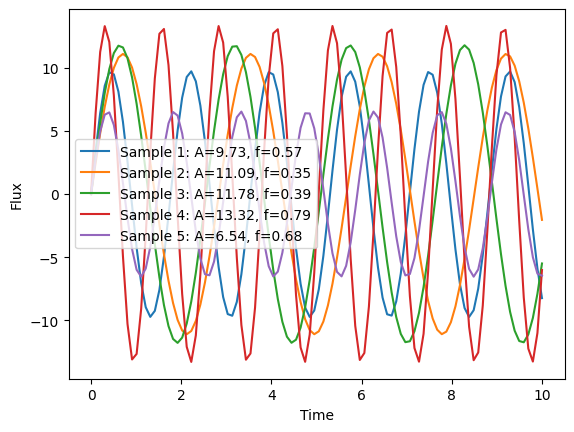

In [5]:
import matplotlib.pyplot as plt

times = np.linspace(0, 10, 100)
wavelengths = np.array([500])

fluxes = source.evaluate_sed(times, wavelengths, graph_state=state)

for i in range(5):
    amp = state["source"]["amplitude"][i]
    freq = state["source"]["frequency"][i]
    label = f"Sample {i + 1}: A={amp:.2f}, f={freq:.2f}"
    plt.plot(times, fluxes[i, :, 0], label=label)
plt.xlabel("Time")
plt.ylabel("Flux")
plt.legend()
plt.show()

A more complex example is using the same `modeldag.ModelDAG` to generate related parameters for a host and a source.

In [6]:
dag_dict = {
    "host_ra": {"func": np.random.uniform, "kwargs": {"low": 0.0, "high": 360.0}},
    "host_dec": {"func": np.random.uniform, "kwargs": {"low": -90.0, "high": 90.0}},
    "source_ra": {"func": np.random.normal, "kwargs": {"loc": "@host_ra", "scale": 0.001}},
    "source_dec": {"func": np.random.normal, "kwargs": {"loc": "@host_dec", "scale": 0.001}},
}
host_source_params = ModelDAGNode(modeldag.ModelDAG(dag_dict))

state = host_source_params.sample_parameters(num_samples=5)
print(state)

ModelDAGNode:_non_func_0:
    host_ra: [341.2899243  139.5996536  245.48920598 215.10364213  33.36435976]
    host_dec: [ 56.12035744 -16.63566961 -28.3143023    3.21396149 -39.41094735]
    source_ra: [341.29103865 139.59892897 245.48829608 215.10399262  33.36357123]
    source_dec: [ 56.11973382 -16.63564797 -28.31331627   3.21326978 -39.4106833 ]


We we could feed into a combined model (for more detail on the additive models, see the [Simulating Combinations of Objects notebook](https://lightcurvelynx.readthedocs.io/en/latest/notebooks/host_source_models.html))

In [7]:
from lightcurvelynx.models.basic_models import SinWaveModel, ConstantSEDModel
from lightcurvelynx.models.multi_object_model import AdditiveMultiObjectModel

host_model = ConstantSEDModel(
    brightness=5.0,
    ra=host_source_params.host_ra,
    dec=host_source_params.host_dec,
    node_label="host",
)

source_model = SinWaveModel(
    amplitude=3.0,
    frequency=1.0,
    t0=0.0,
    ra=host_source_params.source_ra,
    dec=host_source_params.source_dec,
)

model = AdditiveMultiObjectModel(
    objects=[source_model, host_model],
    ra=source_model.ra,
    dec=source_model.dec,
    node_label="combined",
)
state = model.sample_parameters(num_samples=1)
print(state)

ModelDAGNode:_non_func_2:
    host_ra: 129.39333407664455
    host_dec: 60.15070919504622
    source_ra: 129.39224272030174
    source_dec: 60.149701686284025
SinWaveModel_1:
    ra: 129.39224272030174
    dec: 60.149701686284025
    redshift: None
    t0: 0.0
    distance: None
    brightness: 0.0
    amplitude: 3.0
    frequency: 1.0
host:
    ra: 129.39333407664455
    dec: 60.15070919504622
    redshift: None
    t0: None
    distance: None
    brightness: 5.0
combined:
    ra: 129.39224272030174
    dec: 60.149701686284025
    redshift: None
    t0: None
    distance: None


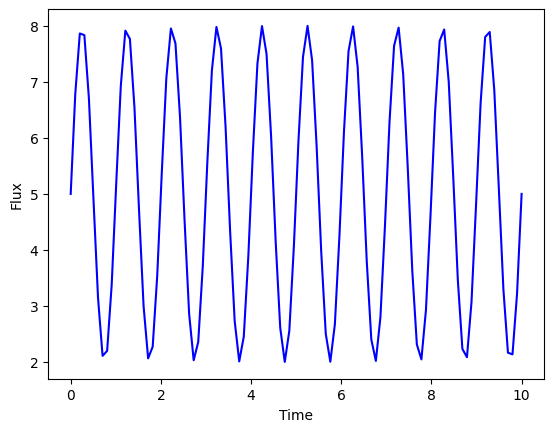

In [8]:
times = np.linspace(0, 10, 100)
wavelengths = np.array([500])

fluxes = model.evaluate_sed(times, wavelengths, graph_state=state)

plt.plot(times, fluxes[:, 0], color="blue")
plt.xlabel("Time")
plt.ylabel("Flux")
plt.show()